# Step 2. 전처리 + Feature Engineering (Long-Panel)

| 항목 | 내용 |
|------|------|
| **자산 유니버스** | ETF 22종 (개별주 8종 제외) |
| **데이터 구조** | Long-Panel [Date x Ticker] |
| **타겟** | 자산별 forward 21d log return + quintile label |
| **산출물** | data/df_panel.csv |

### 설계 근거
- 개별주 제외: 생존편향 방지
- Long-Panel: Gu et al.(2020) 방식, 22 ETF x 2500일 ~ 55,000행
- 자산 특성 피처: ticker 원-핫 대신 수치(Beta, Rate Sensitivity, Momentum)

In [1]:
# Imports & Data Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

DATA_DIR = 'data'

portfolio_prices = pd.read_csv(f'{DATA_DIR}/portfolio_prices.csv', index_col='Date', parse_dates=True)
external_prices  = pd.read_csv(f'{DATA_DIR}/external_prices.csv',  index_col='Date', parse_dates=True)
fred_data        = pd.read_csv(f'{DATA_DIR}/fred_data.csv',        index_col='Date', parse_dates=True)

print('portfolio_prices:', portfolio_prices.shape)
print('external_prices :', external_prices.shape)
print('fred_data       :', fred_data.shape)

portfolio_prices: (2609, 30)
external_prices : (2609, 12)
fred_data       : (2609, 8)


## 2-1. ETF Universe (22종)

개별주 8종(AAPL, MSFT, AMZN, GOOGL, JPM, JNJ, PG, XOM) 생존편향 문제로 제외.

In [2]:
# 2-1. ETF Universe 정의
ETF_UNIVERSE = {
    # Index ETFs (5)
    'SPY':  ('equity',        'us_large_broad'),
    'QQQ':  ('equity',        'us_large_tech'),
    'IWM':  ('equity',        'us_small'),
    'EFA':  ('equity',        'dm_ex_us'),
    'EEM':  ('equity',        'em'),
    # Bond ETFs (4)
    'TLT':  ('bond',          'us_long_treasury'),
    'AGG':  ('bond',          'us_agg'),
    'SHY':  ('bond',          'us_short_treasury'),
    'TIP':  ('bond',          'us_tips'),
    # Alternative (2)
    'GLD':  ('alt',           'gold'),
    'DBC':  ('alt',           'commodity_broad'),
    # Sector ETFs (11)
    'XLK':  ('equity_sector', 'tech'),
    'XLF':  ('equity_sector', 'financial'),
    'XLE':  ('equity_sector', 'energy'),
    'XLV':  ('equity_sector', 'healthcare'),
    'VOX':  ('equity_sector', 'communication'),
    'XLY':  ('equity_sector', 'cons_disc'),
    'XLP':  ('equity_sector', 'cons_staples'),
    'XLI':  ('equity_sector', 'industrial'),
    'XLU':  ('equity_sector', 'utilities'),
    'XLRE': ('equity_sector', 'real_estate'),
    'XLB':  ('equity_sector', 'materials'),
}
ETF_LIST = list(ETF_UNIVERSE.keys())
etf_prices = portfolio_prices[ETF_LIST].copy()
print(f'ETF 유니버스: {len(ETF_LIST)}종')
print(f'Shape: {etf_prices.shape}')
etf_prices.tail(3)

ETF 유니버스: 22종
Shape: (2609, 22)


,SPY,QQQ,IWM,EFA,EEM,TLT,AGG,SHY,TIP,GLD,...,XLF,XLE,XLV,VOX,XLY,XLP,XLI,XLU,XLRE,XLB
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-29,685.976562,620.088135,249.436295,96.279999,54.660000,87.095642,99.185928,82.112717,110.150002,398.600006,...,55.037090,44.330357,155.172089,193.341705,120.607719,77.841850,156.430450,42.562428,40.358734,45.537491
2025-12-30,685.138916,618.649902,247.589569,96.440002,54.880001,86.887970,99.146317,82.132545,110.129997,398.890015,...,54.897804,44.668152,155.042618,194.249557,120.118706,77.712578,155.981705,42.661732,40.448135,45.527534
2025-12-31,685.138916,618.649902,247.589569,96.440002,54.880001,86.887970,99.146317,82.132545,110.129997,398.890015,...,54.897804,44.668152,155.042618,194.249557,120.118706,77.712578,155.981705,42.661732,40.448135,45.527534


## 2-2. 수익률 계산

- ETF 22종: 로그 수익률 ln(P_t / P_{t-1})
- VIX 계열 (^VIX, ^VIX9D, ^VIX3M, ^VIX6M, ^SKEW): .diff() 차분
- FRED 스프레드 (T10Y2Y, BAMLH0A0HYM2): 수준 유지
- DGS10: .diff(5) 차분

In [3]:
# 2-2. 수익률 계산
etf_ret = np.log(etf_prices / etf_prices.shift(1))

VIX_COLS = ['^VIX', '^VIX9D', '^VIX3M', '^VIX6M', '^SKEW']
ext_level = [c for c in VIX_COLS if c in external_prices.columns]
ext_ret_c = [c for c in external_prices.columns if c not in ext_level]

ext_ret  = np.log(external_prices[ext_ret_c] / external_prices[ext_ret_c].shift(1))
ext_diff = external_prices[ext_level].diff()

print('ETF 로그 수익률 :', etf_ret.shape)
etf_ret.tail(3)

ETF 로그 수익률 : (2609, 22)


,SPY,QQQ,IWM,EFA,EEM,TLT,AGG,SHY,TIP,GLD,...,XLF,XLE,XLV,VOX,XLY,XLP,XLI,XLU,XLRE,XLB
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-29,-0.003570,-0.004852,-0.006144,-0.003008,-0.002558,0.003754,0.001199,0.000483,0.000908,-0.044504,...,-0.005408,0.009457,-0.001539,-0.000774,-0.009881,0.000639,-0.002165,0.001868,0.002711,-0.008057
2025-12-30,-0.001222,-0.002322,-0.007431,0.001660,0.004017,-0.002387,-0.000399,0.000241,-0.000182,0.000727,...,-0.002534,0.007591,-0.000835,0.004685,-0.004063,-0.001662,-0.002873,0.002330,0.002213,-0.000219
2025-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 2-3. 거시 파생변수 15개

모든 자산에 공통 브로드캐스트되는 매크로 피처.

| # | 변수 | 수식 |
|---|------|------|
| 1-4 | VIX_level, VIX_contango, VIX_slope_9d_3m, VIX_slope_3m_6m | VIX 기간구조 |
| 5-6 | SKEW_level, SKEW_zscore | 꼬리 위험 |
| 7-8 | Cu_Au_ratio, Cu_Au_ratio_chg | 실물 경기 |
| 9-10 | HY_spread, HY_spread_chg | 신용 시장 |
| 11-12 | yield_curve, yield_curve_inv | 경기선행 |
| 13-14 | claims_4wma, claims_zscore | 노동시장 |
| 15 | WEI_level, sahm_indicator | 성장/침체 |

In [4]:
# 2-3. 거시 파생변수 15개
idx = etf_prices.index

def rfill(df, col, idx):
    return df[col].reindex(idx).ffill()

vix_   = rfill(external_prices, '^VIX',  idx)
vix9d_ = rfill(external_prices, '^VIX9D', idx)
vix3m_ = rfill(external_prices, '^VIX3M', idx)
vix6m_ = rfill(external_prices, '^VIX6M', idx)
skew_  = rfill(external_prices, '^SKEW',  idx)
cu_    = rfill(external_prices, 'HG=F',   idx)
au_    = rfill(external_prices, 'GC=F',   idx)
fred_  = fred_data.reindex(idx).ffill()

macro = pd.DataFrame(index=idx)

# VIX 기간구조 (1-4)
macro['VIX_level']       = vix_
macro['VIX_contango']    = vix3m_ / vix_ - 1
macro['VIX_slope_9d_3m'] = vix3m_ - vix9d_
macro['VIX_slope_3m_6m'] = vix6m_ - vix3m_

# SKEW (5-6)
macro['SKEW_level']  = skew_
macro['SKEW_zscore'] = (skew_ - skew_.rolling(63).mean()) / skew_.rolling(63).std()

# 구리/금 실물 경기 (7-8)
cu_au = cu_ / au_
macro['Cu_Au_ratio']     = cu_au
macro['Cu_Au_ratio_chg'] = cu_au.diff(21)

# HY 신용스프레드 (9-10)
hy = fred_['BAMLH0A0HYM2']
macro['HY_spread']     = hy
macro['HY_spread_chg'] = hy.diff(5)

# 수익률 곡선 (11-12)
macro['yield_curve']     = fred_['T10Y2Y']
macro['yield_curve_inv'] = (fred_['T10Y2Y'] < 0).astype(int)

# 실업수당 (13-14)
claims_ma = fred_['ICSA'].rolling(28, min_periods=5).mean()
macro['claims_4wma']   = claims_ma
macro['claims_zscore'] = (claims_ma - claims_ma.rolling(260).mean()) / claims_ma.rolling(260).std()

# 성장/침체 (15)
macro['WEI_level']      = fred_['WEI']
macro['sahm_indicator'] = fred_['SAHMREALTIME']

# 금리 차분 (자산 특성 피처용)
macro['DGS10_chg5'] = fred_['DGS10'].diff(5)

print('Macro features:', macro.shape)
macro.dropna(how='all').tail(3)

Macro features: (2609, 17)


,VIX_level,VIX_contango,VIX_slope_9d_3m,VIX_slope_3m_6m,SKEW_level,SKEW_zscore,Cu_Au_ratio,Cu_Au_ratio_chg,HY_spread,HY_spread_chg,yield_curve,yield_curve_inv,claims_4wma,claims_zscore,WEI_level,sahm_indicator,DGS10_chg5
Date,,,,,,,,,,,,,,,,,
2025-12-29,14.20,0.254930,6.45,2.780001,150.470001,0.483268,0.001269,0.000040,2.87,-0.01,0.67,0,220964.285714,-0.890132,2.51,0.35,-0.05
2025-12-30,14.33,0.240056,6.31,2.920000,148.330002,0.115920,0.001311,0.000080,2.84,0.01,0.69,0,220285.714286,-0.998071,2.51,0.35,-0.04
2025-12-31,14.33,0.240056,6.31,2.920000,148.330002,0.106274,0.001311,0.000078,2.81,-0.03,0.71,0,219607.142857,-1.104965,2.51,0.35,0.03


## 2-4. 자산별 특성 피처

Pooled Panel에서 ticker 원-핫 인코딩 대신 수치형 특성으로 자산 구분.
트리 모델이 beta_60d=1.4, rate_corr=-0.3 같은 수치로 XLK vs TLT 구분 가능.

| 피처 | 수식 | 역할 |
|------|------|------|
| ret_1m | log(P_t/P_{t-21}) | 단기 모멘텀 |
| ret_3m | log(P_t/P_{t-63}) | 중기 모멘텀 |
| ret_6m | log(P_t/P_{t-126}) | 6M 모멘텀 |
| ret_12m | log(P_t/P_{t-252}) | 12M 모멘텀 |
| vol_21d | std(ret,21)*sqrt(252) | 단기 변동성 |
| vol_63d | std(ret,63)*sqrt(252) | 중기 변동성 |
| vol_ratio | vol_21d/vol_63d | 변동성 가속 |
| beta_60d | Cov(r,SPY)/Var(SPY) 60d | 시장 민감도 |
| beta_120d | 동일, 120d | 장기 시장 민감도 |
| rate_corr_60d | corr(ret, DGS10_chg5, 60d) | 금리 민감도 |
| rsi_14d | RSI(14) | 과매수/과매도 |

In [5]:
# 2-4. 자산별 특성 피처
def rolling_beta(asset_ret, market_ret, window):
    cov = asset_ret.rolling(window).cov(market_ret)
    var = market_ret.rolling(window).var()
    return cov / var

def compute_rsi(price, window=14):
    delta = price.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

spy_ret   = etf_ret['SPY']
rate_chg5 = macro['DGS10_chg5']

char_frames = {}
for ticker in ETF_LIST:
    r  = etf_ret[ticker]
    p  = etf_prices[ticker]
    ch = pd.DataFrame(index=idx)
    # 모멘텀
    ch['ret_1m']  = np.log(p / p.shift(21))
    ch['ret_3m']  = np.log(p / p.shift(63))
    ch['ret_6m']  = np.log(p / p.shift(126))
    ch['ret_12m'] = np.log(p / p.shift(252))
    # 변동성
    ch['vol_21d']   = r.rolling(21).std() * np.sqrt(252)
    ch['vol_63d']   = r.rolling(63).std() * np.sqrt(252)
    ch['vol_ratio'] = ch['vol_21d'] / ch['vol_63d']
    # 시장 Beta
    ch['beta_60d']  = rolling_beta(r, spy_ret, 60)
    ch['beta_120d'] = rolling_beta(r, spy_ret, 120)
    # 금리 민감도
    ch['rate_corr_60d'] = r.rolling(60).corr(rate_chg5)
    # RSI
    ch['rsi_14d'] = compute_rsi(p, 14)
    char_frames[ticker] = ch

print(f'자산별 피처: {len(char_frames)} tickers x {len(char_frames["SPY"].columns)} features')
char_frames['SPY'].dropna().tail(3)

자산별 피처: 22 tickers x 11 features


,ret_1m,ret_3m,ret_6m,ret_12m,vol_21d,vol_63d,vol_ratio,beta_60d,beta_120d,rate_corr_60d,rsi_14d
Date,,,,,,,,,,,
2025-12-29,0.009456,0.031560,0.100994,0.165988,0.084493,0.126043,0.670352,1.0,1.0,-0.141581,57.209099
2025-12-30,0.012810,0.029187,0.107252,0.180151,0.082761,0.126083,0.656397,1.0,1.0,-0.142075,51.679300
2025-12-31,0.010959,0.029201,0.107800,0.178602,0.082659,0.126083,0.655595,1.0,1.0,-0.144378,49.845997


## 2-5. Long-Panel 구축 [Date x Ticker]

22 ETF x ~2,500일 = ~55,000행

In [6]:
# 2-5. Long-Panel 구축
rows = []
for ticker in ETF_LIST:
    asset_class, sub_class = ETF_UNIVERSE[ticker]
    df_t = pd.DataFrame({
        'Date'        : idx,
        'Ticker'      : ticker,
        'asset_class' : asset_class,
        'sub_class'   : sub_class,
        'price'       : etf_prices[ticker].values,
        'ret'         : etf_ret[ticker].values,
    })
    df_t = df_t.join(char_frames[ticker].reset_index(drop=True))
    df_t = df_t.join(macro.reset_index(drop=True))
    rows.append(df_t)

df_panel = pd.concat(rows, ignore_index=True)
df_panel = df_panel.sort_values(['Date', 'Ticker']).reset_index(drop=True)

print('Long-Panel shape:', df_panel.shape)
print('Tickers:', df_panel['Ticker'].nunique())
print('Date range:', df_panel['Date'].min().date(), '~', df_panel['Date'].max().date())
df_panel.head(6)

Long-Panel shape: (57398, 34)
Tickers: 22
Date range: 2016-01-01 ~ 2025-12-31


,Date,Ticker,asset_class,sub_class,price,ret,ret_1m,ret_3m,ret_6m,ret_12m,...,Cu_Au_ratio_chg,HY_spread,HY_spread_chg,yield_curve,yield_curve_inv,claims_4wma,claims_zscore,WEI_level,sahm_indicator,DGS10_chg5
0,2016-01-01,AGG,bond,us_agg,81.308701,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN
1,2016-01-01,DBC,alt,commodity_broad,11.210503,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN
2,2016-01-01,EEM,equity,em,25.081514,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN
3,2016-01-01,EFA,equity,dm_ex_us,42.864738,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN
4,2016-01-01,GLD,alt,gold,102.889999,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN
5,2016-01-01,IWM,equity,us_small,96.464249,NaN,NaN,NaN,NaN,NaN,...,NaN,7.1,NaN,1.22,0,NaN,NaN,0.79,-0.03,NaN


## 2-6. 타겟 변수 생성

- fwd_ret_21d: 회귀 타겟 (RF/LLM용). ln(P_{t+21}/P_t)
- fwd_label_21d: 분류 타겟 1~5 (XGBoost/TabPFN용)
- 주의: fwd_label_21d는 EDA용 full-sample qcut. 실제 학습 시 IS 윈도우 내 재계산 필수

In [7]:
# 2-6. 타겟 생성
out = []
for ticker, g in df_panel.groupby('Ticker', sort=False):
    g = g.sort_values('Date').copy()
    p = g['price']
    for h in [5, 21, 63]:
        g[f'fwd_ret_{h}d'] = np.log(p.shift(-h) / p)
    out.append(g)

df_panel = pd.concat(out).sort_values(['Date','Ticker']).reset_index(drop=True)

def safe_qcut(s):
    try:
        return pd.qcut(s, q=5, labels=[1,2,3,4,5], duplicates='drop').astype(float)
    except:
        return np.nan

df_panel['fwd_label_21d'] = (
    df_panel.groupby('Ticker')['fwd_ret_21d']
    .transform(safe_qcut)
)

print('타겟 생성 완료')
df_panel[['Date','Ticker','ret','fwd_ret_5d','fwd_ret_21d','fwd_ret_63d','fwd_label_21d']].tail(6)

타겟 생성 완료


,Date,Ticker,ret,fwd_ret_5d,fwd_ret_21d,fwd_ret_63d,fwd_label_21d
57392,2025-12-31,XLK,0.0,NaN,NaN,NaN,NaN
57393,2025-12-31,XLP,0.0,NaN,NaN,NaN,NaN
57394,2025-12-31,XLRE,0.0,NaN,NaN,NaN,NaN
57395,2025-12-31,XLU,0.0,NaN,NaN,NaN,NaN
57396,2025-12-31,XLV,0.0,NaN,NaN,NaN,NaN
57397,2025-12-31,XLY,0.0,NaN,NaN,NaN,NaN


## 2-7. 결측치 처리 및 저장

In [8]:
# 2-7. 결측 처리 & 저장
WARMUP_COLS = ['beta_120d', 'ret_12m', 'vol_63d', 'claims_zscore']
df_panel_clean = df_panel.dropna(subset=WARMUP_COLS).copy()

print(f'전체 패널      : {df_panel.shape}')
print(f'워밍업 제거 후 : {df_panel_clean.shape}')
print(f'Ticker 수      : {df_panel_clean["Ticker"].nunique()}')
print(f'기간           : {df_panel_clean["Date"].min().date()} ~ {df_panel_clean["Date"].max().date()}')
print(f'학습 가능 행   : {df_panel_clean["fwd_ret_21d"].notna().sum():,}')

df_panel_clean.to_csv(f'{DATA_DIR}/df_panel.csv', index=False)
print(f'저장 완료: {DATA_DIR}/df_panel.csv')

전체 패널      : (57398, 38)
워밍업 제거 후 : (51612, 38)
Ticker 수      : 22
기간           : 2017-01-04 ~ 2025-12-31
학습 가능 행   : 51,150
저장 완료: data/df_panel.csv


## 2-8. EDA: 피처 분산도 검증

핵심 질문: 22개 자산이 피처 공간에서 충분히 구분되는가?

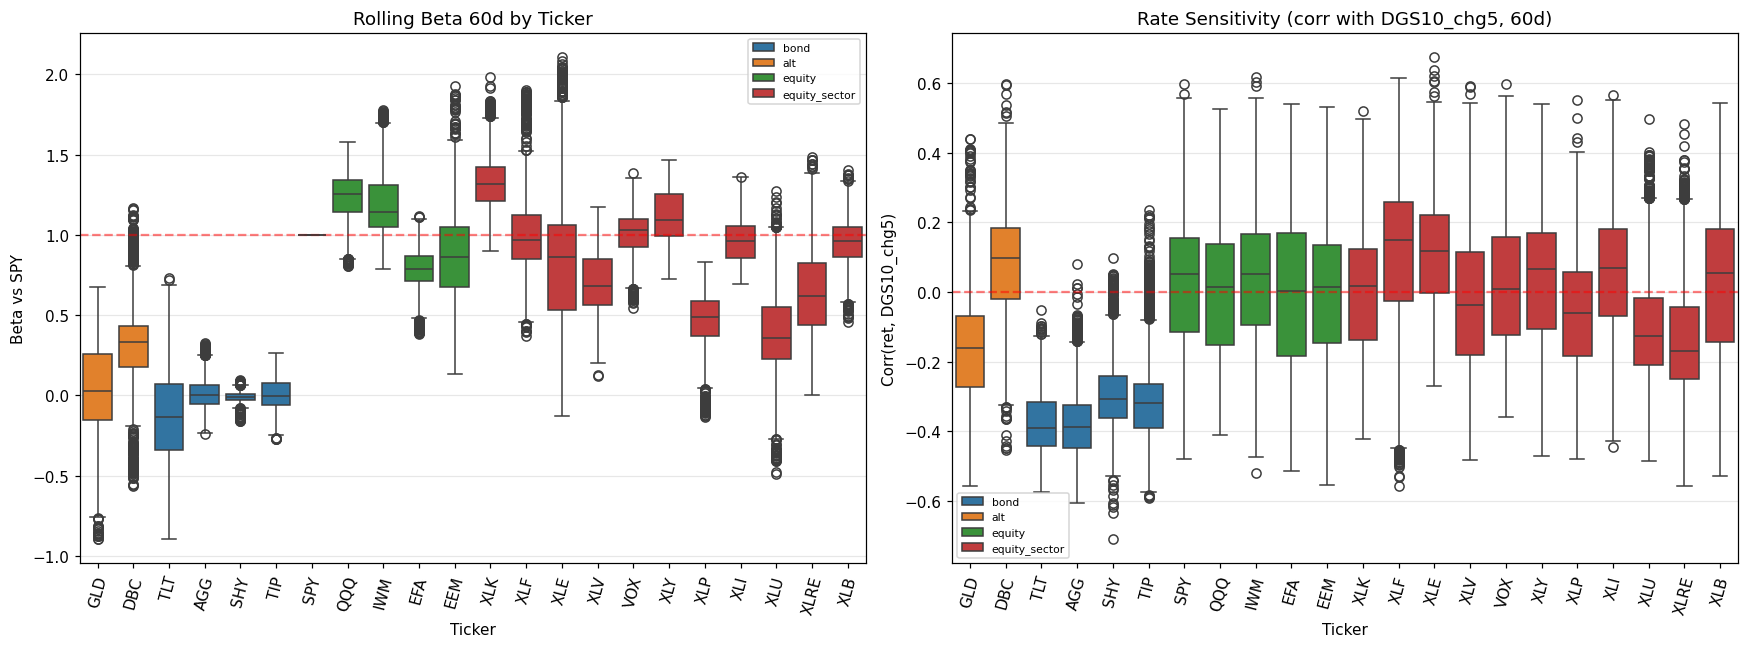

In [9]:
# Viz 1: Beta & Rate Sensitivity 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = sorted(ETF_LIST, key=lambda t: ETF_UNIVERSE[t][0])

ax = axes[0]
sns.boxplot(data=df_panel_clean, x='Ticker', y='beta_60d',
            hue='asset_class', order=order, dodge=False, ax=ax)
ax.axhline(1.0, color='red', ls='--', alpha=0.5)
ax.set_title('Rolling Beta 60d by Ticker')
ax.set_ylabel('Beta vs SPY')
plt.setp(ax.get_xticklabels(), rotation=75)
ax.legend(fontsize=7)

ax = axes[1]
sns.boxplot(data=df_panel_clean, x='Ticker', y='rate_corr_60d',
            hue='asset_class', order=order, dodge=False, ax=ax)
ax.axhline(0.0, color='red', ls='--', alpha=0.5)
ax.set_title('Rate Sensitivity (corr with DGS10_chg5, 60d)')
ax.set_ylabel('Corr(ret, DGS10_chg5)')
plt.setp(ax.get_xticklabels(), rotation=75)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

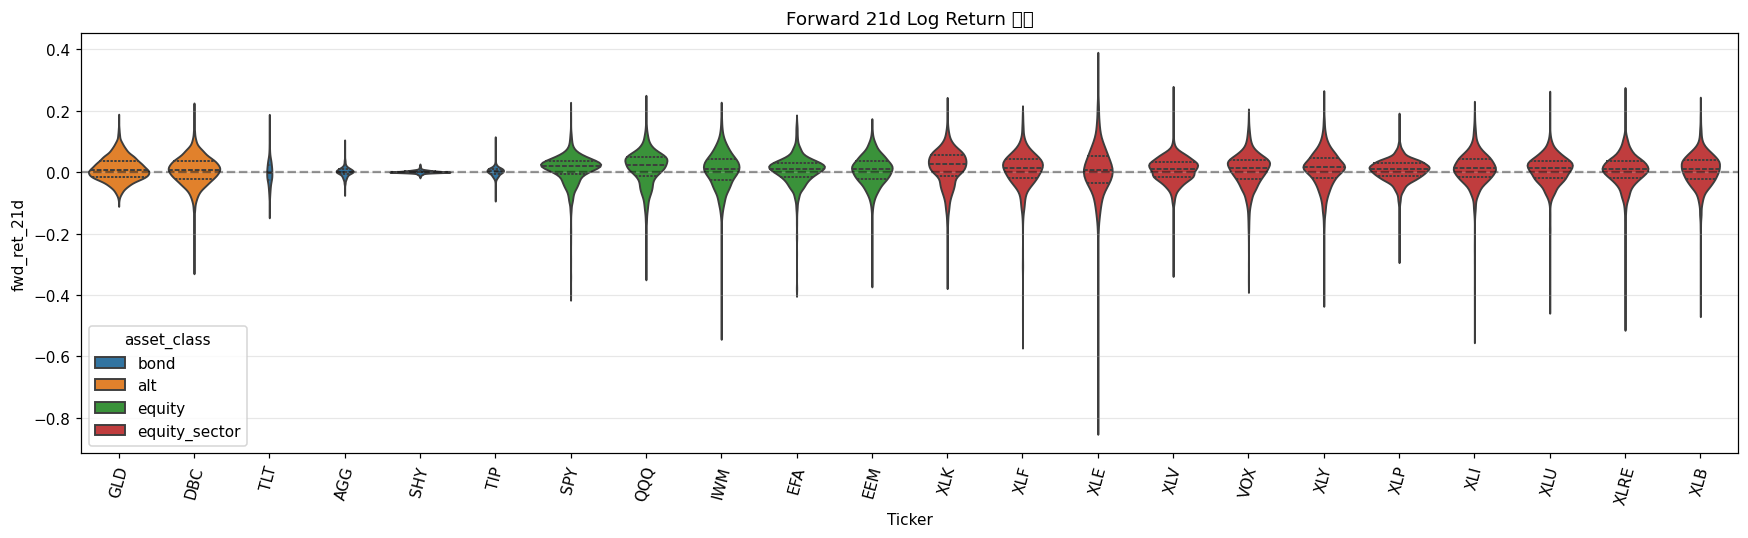

In [10]:
# Viz 2: Forward 21d Return 분포 (타겟 분산도)
fig, ax = plt.subplots(figsize=(16, 5))
order = sorted(ETF_LIST, key=lambda t: ETF_UNIVERSE[t][0])
df_t = df_panel_clean.dropna(subset=['fwd_ret_21d'])
sns.violinplot(data=df_t, x='Ticker', y='fwd_ret_21d',
               hue='asset_class', order=order, dodge=False, ax=ax, inner='quartile')
ax.axhline(0, color='k', ls='--', alpha=0.4)
ax.set_title('Forward 21d Log Return 분포')
ax.set_ylabel('fwd_ret_21d')
plt.setp(ax.get_xticklabels(), rotation=75)
plt.tight_layout()
plt.show()

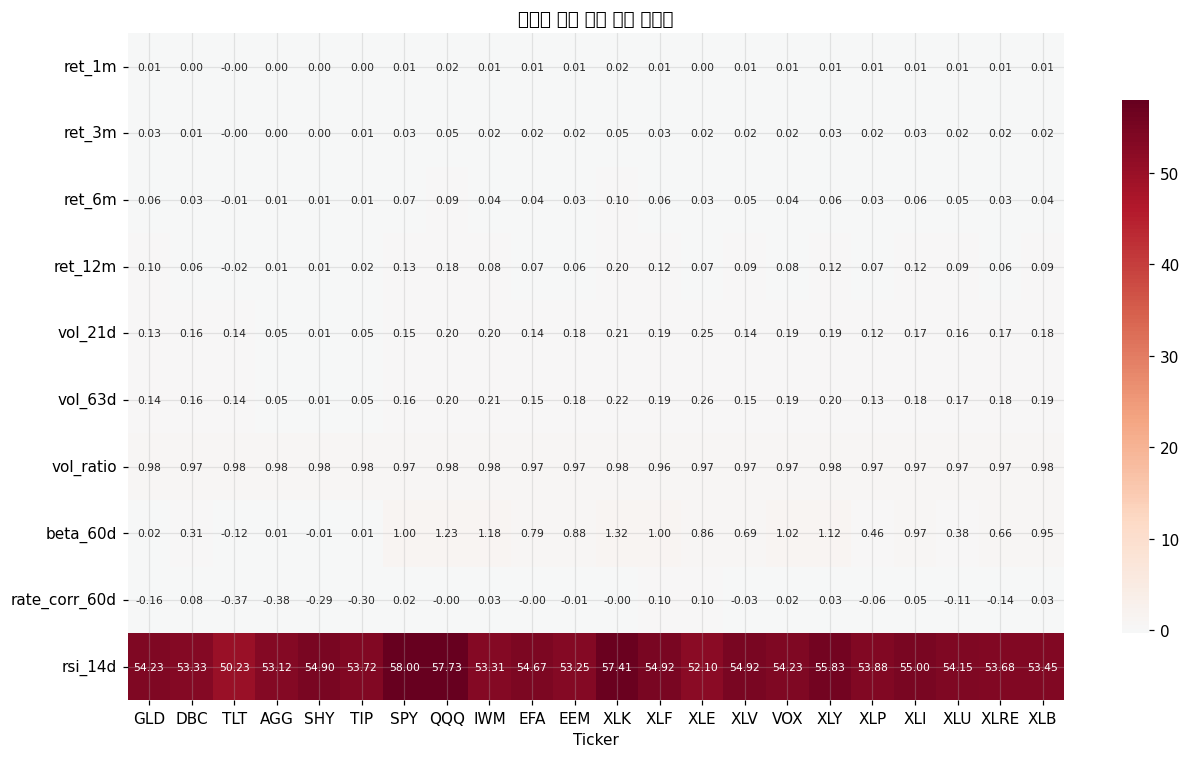

색상 차이 클수록 자산 구분력 높음


In [11]:
# Viz 3: 자산별 평균 피처 히트맵
CHAR_COLS = ['ret_1m','ret_3m','ret_6m','ret_12m',
             'vol_21d','vol_63d','vol_ratio',
             'beta_60d','rate_corr_60d','rsi_14d']
order = sorted(ETF_LIST, key=lambda t: ETF_UNIVERSE[t][0])
heatmap_df = df_panel_clean.groupby('Ticker')[CHAR_COLS].mean().loc[order]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_df.T, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('자산별 평균 특성 피처 히트맵')
plt.tight_layout()
plt.show()
print('색상 차이 클수록 자산 구분력 높음')

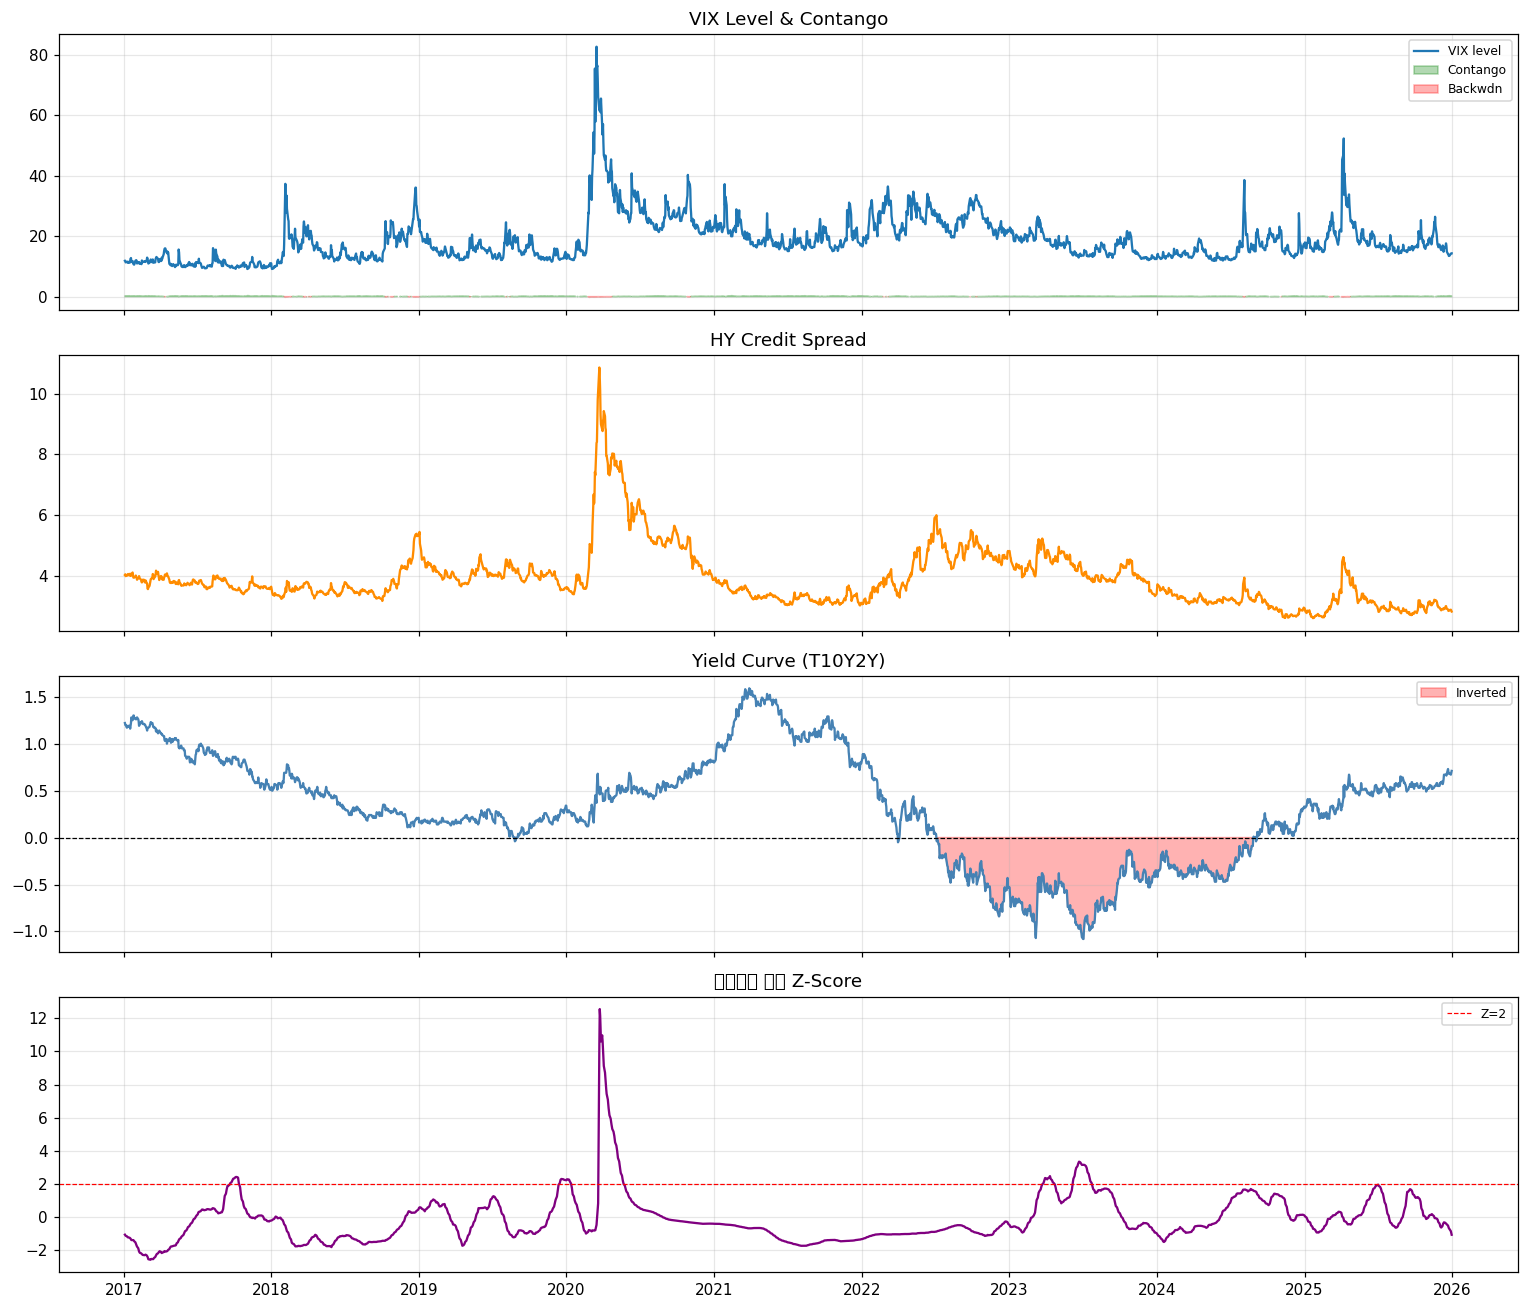

In [12]:
# Viz 4: 매크로 피처 시계열
macro_ts = df_panel_clean[df_panel_clean['Ticker']=='SPY'].set_index('Date').sort_index()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
ax.plot(macro_ts.index, macro_ts['VIX_level'], label='VIX level')
ax.fill_between(macro_ts.index, 0, macro_ts['VIX_contango'],
                where=macro_ts['VIX_contango']>0, alpha=0.3, color='green', label='Contango')
ax.fill_between(macro_ts.index, 0, macro_ts['VIX_contango'],
                where=macro_ts['VIX_contango']<0, alpha=0.3, color='red', label='Backwdn')
ax.set_title('VIX Level & Contango')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(macro_ts.index, macro_ts['HY_spread'], color='darkorange')
ax.set_title('HY Credit Spread')

ax = axes[2]
yc = macro_ts['yield_curve']
ax.plot(macro_ts.index, yc, color='steelblue')
ax.fill_between(macro_ts.index, yc, 0, where=yc<0, color='red', alpha=0.3, label='Inverted')
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_title('Yield Curve (T10Y2Y)')
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(macro_ts.index, macro_ts['claims_zscore'], color='purple')
ax.axhline(2, color='red', ls='--', lw=0.8, label='Z=2')
ax.set_title('실업수당 청구 Z-Score')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2-9. 요약 & Step3 유의사항

### 산출물: data/df_panel.csv

| 컬럼 그룹 | 내용 |
|-----------|------|
| 식별 | Date, Ticker, asset_class, sub_class |
| 수익/가격 | ret, price |
| 자산 특성 (11) | ret_1m/3m/6m/12m, vol_21d/63d/ratio, beta_60d/120d, rate_corr_60d, rsi_14d |
| 거시 파생 (16) | VIX, SKEW, Cu/Au, HY, yield curve, claims, WEI, sahm, DGS10_chg5 |
| 타겟 | fwd_ret_5d/21d/63d, fwd_label_21d |

### Step3 Walk-Forward 주의사항
1. IS 라벨 재계산: fwd_label_21d는 EDA용. 학습 시 IS 윈도우 내 pd.qcut 재계산
2. Purge+Embargo: fwd_ret_21d 21일 겹침 -> 21일 purge + 5일 embargo
3. 분산도 체크: OOS Q값 납작하면 피처 재점검
4. XGBoost: enable_categorical=True 로 asset_class 직접 투입 가능